# **🚴‍♀️ Проект спринта: Нелинейные модели против сочинской погоды**

Компания **BikeSochi**, оператор городского велопроката в Сочи, обратилась за помощью в улучшении системы прогнозирования почасового спроса на велосипеды.

До этого аналитики компании использовали простую линейную регрессию — одну из самых базовых моделей машинного обучения.

Однако её прогнозы часто ошибались:



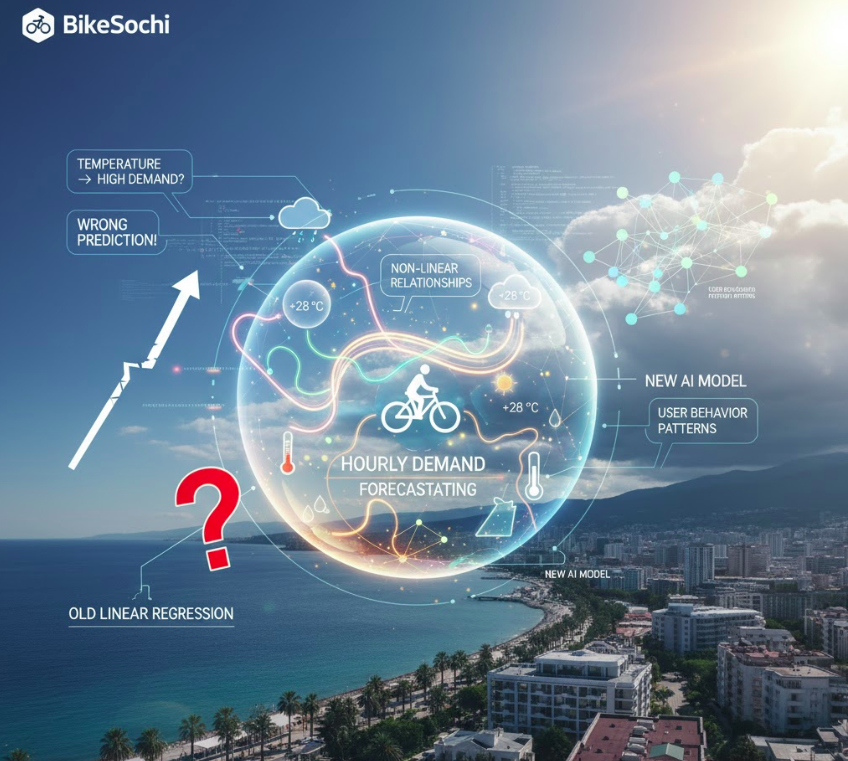

> «Модель видела, что температура выросла — и сразу предсказывала высокий спрос.
Но не понимала, что +28 °C под палящим солнцем и +28 °C после дождя — это две совсем разные ситуации.»

Погода в Сочи меняется быстро, и влияние факторов — нелинейное: температура, влажность, солнечная радиация, осадки влияют на поведение людей не по простым прямым зависимостям.



---



В рамках этого проекта вы выступаете в роли аналитиков компании **BikeSochi, которые должны предложить новую, более гибкую модель прогнозирования.**

**В этом проекте вы:**

1. Изучите предоставленную компанией baseline-модель (линейную регрессию);

2. Обучите новые модели — K-ближайших соседей (KNN) и решающее дерево (Decision Tree);

3. Проведёте подбор гиперпараметров с помощью библиотеки Optuna;

4. Сравните результаты всех подходов, выберете наилучший и аргументируете свой выбор.

Дополнительно: Реализуете собственный класс-трансформер и интегрируете его в пайплайн.


**К концу проекта у вас будет:**

— улучшенная модель прогноза почасового спроса на велосипеды в Сочи;

— отчёт с метриками и сравнением подходов;

— сохранённый пайплайн лучшей модели.



---



Импортируем необходимые библиотеки:

In [1]:
!pip install optuna

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import joblib
from phik import phik_matrix

from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, OrdinalEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold,train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE=42

In [3]:
!pip freeze > requirements.txt

Загрузим датасеты:

In [4]:
try:
    df_train = pd.read_csv('data/ds_s14_train_data.csv')
    df_test = pd.read_csv('data/ds_s14_test_data.csv')
    print('Датасеты загружены успешно!')
except:
    df_train = pd.read_csv('ds_s14_train_data.csv')
    df_test = pd.read_csv('ds_s14_test_data.csv')
    print('Датасеты загружены успешно!')

Датасеты загружены успешно!


Проверим загрузку датасетов:

In [5]:
df_train.sample()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
6592,31.2,63.0,1.7,1537.0,23.3,0.0,0.0,0.0,Summer,No Holiday,Yes,False,True,False,False,1511


In [6]:
df_test.sample()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
92,23.9,71.0,4.7,1982.0,18.3,0.0,0.0,0.0,Autumn,No Holiday,Yes,False,True,False,False,562


Строки выводятся без проблем.

# **Часть 1: Базовая модель**

В этой части вы познакомитесь с тем, как работает baseline-модель, которую использовала компания BikeSochi до внедрения улучшенной версии.

Компания предоставила вам:

— baseline_linear_regression_pipeline.pkl — готовый обученный пайплайн (без исходного кода);

— краткое описание того, как он был устроен;

— тренировочную и тестовую выборки, которые можно использовать для оценки модели.

Это значит, что вам не нужно обучать эту модель заново — вы просто загружаете её и проверяете качество (например, на метриках RMSE, MAE, R²).

**Совет:**
1. Убедитесь, что у вас есть baseline_linear_regression_pipeline.pkl и train_data.csv и test_data.csv.

2. Разделите тестовый набор на признаки (X) и целевую переменную Rented Bike Count.

3. Загрузите .pkl файл — это готовый пайплайн, который сам обрабатывает данные и делает предсказания. Модель автоматически применяет трансформации и возвращает прогнозы.

4. Посчитайте RMSE, MAE и R², эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.

Загрузим модель которую нам предоставила компания BikeSouth:

In [7]:
try:
    loaded_model = joblib.load('models/baseline_linear_regression_pipeline.joblib')
    print('Модель успешно загружена!')
except:
    loaded_model = joblib.load('models/baseline_linear_regression_pipeline.joblib')
    print('Модель успешно загружена!')

Модель успешно загружена!


Сразу посмотрим на состав загруженного пайплайна:

In [8]:
loaded_model.named_steps.keys()

dict_keys(['preprocessor', 'model'])

Посмотрим на веса модели:

In [9]:
baseline_weights = loaded_model.named_steps['model'].coef_

baseline_features = loaded_model.named_steps['preprocessor'].get_feature_names_out()

baseline_model_feature_weights = pd.DataFrame({
    'feature':baseline_features,
    'weight':baseline_weights,
    'abs_weight': abs(baseline_weights)
})
baseline_model_feature_weights.sort_values('abs_weight', ascending=False)

,feature,weight,abs_weight
16,time__time_period_evening,518.384163,518.384163
15,cat__functioning_day_Yes,468.950829,468.950829
14,cat__functioning_day_No,-468.950829,468.950829
17,time__time_period_late_evening,413.039584,413.039584
0,num__temperature,315.570571,315.570571
18,time__time_period_morning,241.268021,241.268021
11,cat__seasons_Winter,-190.566264,190.566264
8,cat__seasons_Autumn,164.011222,164.011222
1,num__humidity,-126.362276,126.362276
19,time__time_period_night,-116.935350,116.935350


Обратим внимание что все названия признаков приведены к Snake Case. Напишим функцию, которая приводит названия столбцов к snake_case:

In [10]:
def to_snake_case(data):
    df_renamed = data.copy()
    renamed_features = {}
    for col in data.columns:
        renamed_col = col.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('%', '').replace('/', '')
        renamed_features[col] = renamed_col
    df_renamed = df_renamed.rename(columns=renamed_features)
    return df_renamed

Приведем исходные датасеты к Snake Case:

In [11]:
df_train = to_snake_case(df_train)
df_test = to_snake_case(df_test)

print(f'Названия признаков train: {df_train.columns}')
print('')
print(f'Названия признаков test: {df_test.columns}')

Названия признаков train: Index(['temperature', 'humidity', 'wind_speed_ms', 'visibility_10m',
       'dew_point_temperature', 'solar_radiation_mjm2', 'rainfallmm',
       'snowfall_cm', 'seasons', 'holiday', 'functioning_day',
       'time_period_evening', 'time_period_late_evening',
       'time_period_morning', 'time_period_night', 'rented_bike_count'],
      dtype='object')

Названия признаков test: Index(['temperature', 'humidity', 'wind_speed_ms', 'visibility_10m',
       'dew_point_temperature', 'solar_radiation_mjm2', 'rainfallmm',
       'snowfall_cm', 'seasons', 'holiday', 'functioning_day',
       'time_period_evening', 'time_period_late_evening',
       'time_period_morning', 'time_period_night', 'rented_bike_count'],
      dtype='object')


Разделим новые датасеты на матрицу признаков и целевую переменную:

In [12]:
X_train = df_train.drop(columns='rented_bike_count')
y_train = df_train['rented_bike_count']

X_test = df_test.drop(columns='rented_bike_count')
y_test = df_test['rented_bike_count']

Составим таблицу метрик для baseline модели. В качестве метрик будем использовать RMSE, MAE и R2:

In [13]:
y_train_pred_baseline = loaded_model.predict(X_train)
y_test_pred_baseline = loaded_model.predict(X_test)

baseline_results = pd.DataFrame({
    'Data': ['Train', 'Test'],
    'RMSE': [np.sqrt(mean_squared_error(y_train, y_train_pred_baseline)),
            np.sqrt(mean_squared_error(y_test, y_test_pred_baseline))],
    'MAE': [mean_absolute_error(y_train, y_train_pred_baseline),
           mean_absolute_error(y_test, y_test_pred_baseline)],
    'R2': [r2_score(y_train, y_train_pred_baseline),
          r2_score(y_test, y_test_pred_baseline)]
})

baseline_results

,Data,RMSE,MAE,R2
0,Train,412.499623,309.152519,0.592596
1,Test,411.454458,312.531298,0.586293


Мы получили метрики baseline модели. В дальнейшем данные метрики будут использованы для сравнения улучшенных моделей. Так же в данном разделе была разработана функция to_snake_case, которая приводит названия столбцов к snake_case

Т.к. baseline модель - линейная, мы можем выделить по весам модели наиболее влиятельные признаки:
- `Time_Period` - временной период
- `Functioning Day` - Были ли велосипеды арендованы в рабочее время
- `Temperature` - Температура воздуха в градусах Цельсия

# **Часть 2: Улучшение модели — KNN и Decision Tree**

Ваша задача — предложить более гибкую модель прогноза спроса на велосипеды, которая учитывает нюансы сочинской погоды и поведение клиентов.

Вы будете экспериментировать с K-ближайшими соседями (KNN) и решающим деревом (Decision Tree), использовать подбор гиперпараметров с Optuna и внедрять кастомные трансформеры для новых признаков.

**Шаг 1: Изучение постановки задачи:**

Проведите EDA (Exploratory Data Analysis):
1. Посмотрите на распределение целевой переменной Rented Bike Count. Есть ли выбросы или сильные сезонные колебания?
2. Постройте графики зависимости спроса от температуры, осадков, солнечной радиации.
3. Сравните спрос в разные сезоны и праздничные дни.
4. Проверьте корреляции между признаками и целевой переменной.

**Совет:**

Не нужно сразу всё усложнять. Начните с базовых графиков и описательной статистики.



---



**Шаг 2: Разделение данных на тренировочную и валидационную выборки**

> У вас есть доступ к тренировочной и тестовой выборкам.

Тестовый набор используется для финальной оценки модели после тренировки и подбора гиперпараметров.

Вы тренируетесь на тренировочных данных и оцениваете качество через валидацию.

---



**Шаг 3: Обучение новых моделей**

> Теперь пора «проверить, насколько далеко уедут модели» — KNN и Decision Tree могут уловить нелинейные зависимости, недоступные линейной регрессии.

Что нужно сделать:
1. Подготовьте пайплайн для каждой модели:
    * Предобработка данных.
    * Модель (KNN или Decision Tree).
4. Настройте базовые параметры моделей (например, n_neighbors для KNN, max_depth для дерева).

**Совет:**

Начинайте с базовых параметров, чтобы убедиться, что пайплайн работает. Оптимизацию параметров делаем на следующем шаге.

---



**Шаг 4: Подбор гиперпараметров с Optuna**

> Компания хочет точную модель. Optuna поможет найти лучшие параметры для KNN и дерева, чтобы снизить ошибки прогноза.

Что нужно сделать:
1. Определите функцию цели для Optuna.

2. Настройте диапазоны гиперпараметров.

3. Запустите оптимизацию и сохраните лучшие параметры.

**Совет:**

Не бойтесь экспериментировать с небольшими диапазонами сначала, а потом расширять, если модель «не уловила» зависимости.

---



**Шаг 5: Кросс-валидация новых моделей**

Что нужно сделать:
1. Проведите кросс-валидацию для KNN и Decision Tree с оптимальными гиперпараметрами.
2. Сравните метрики с baseline-моделью.
3. Определите, какая модель показывает лучшие результаты на тренировочной выборке.

**Совет:**

Используйте визуализации (bar plot, box plot), чтобы увидеть разброс метрик и стабильность моделей.


---



**Шаг 6: Составление отчёта по моделям**

Что нужно сделать:
1. Составьте таблицу с метриками: baseline, KNN, Decision Tree.
2. Добавьте визуализацию, если необходимо: bar plot или box plot по RMSE/MAE.

Подготовьте выводы:
1. Какая модель лучше справляется с прогнозом?
2. Какие признаки, по вашему мнению, особенно важны?


**Совет:**

Старайтесь объяснить результаты в бизнес-контексте: «Эта модель лучше реагирует на дождь», «Температура и влажность сильно влияют на спрос в пиковые часы».

---



**Шаг 7: Сохранение модели и отчёта**

Что нужно сделать:
1. Выберите финальную, наилучшую модель и оцените её качество на тестовой выборке, чтобы понять, насколько она прогнозирует реальные данные.
2. Подготовьте ноутбук с кодом и комментариями: включите результаты всех экспериментов, метрики моделей, визуализации, а также обоснование выбора финальной модели.

**Совет:**

Документируйте каждый шаг: почему выбраны те или иные гиперпараметры и подходы. В реальной бизнес-задаче это помогает коллегам и руководству понимать решения и доверять модели.

---



**Опционально: Реализация кастомного трансформера**

> Простые признаки вроде температуры или влажности не всегда отражают реальную ситуацию.
Чтобы модель могла лучше прогнозировать спрос на велосипеды, можно создавать новые признаки, которые учитывают особенности погоды или взаимодействия факторов.

Что нужно сделать:
1. Реализуйте класс с методами fit и transform.
2. Вставьте его в пайплайн перед моделью.
3. Проверьте, что трансформер корректно работает с тренировочными данными.

**Совет:**
Если вы решите реализовать трансформер, начинайте с простых комбинаций признаков, чтобы не усложнять модель слишком рано.


---



## EDA

Начнем EDA с тренировочного датасета. Выведем общую информацию о нем:

In [14]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   temperature               7008 non-null   float64
 1   humidity                  6758 non-null   float64
 2   wind_speed_ms             6798 non-null   float64
 3   visibility_10m            6749 non-null   float64
 4   dew_point_temperature     7008 non-null   float64
 5   solar_radiation_mjm2      6798 non-null   float64
 6   rainfallmm                6746 non-null   float64
 7   snowfall_cm               6745 non-null   float64
 8   seasons                   7008 non-null   object 
 9   holiday                   7008 non-null   object 
 10  functioning_day           7008 non-null   object 
 11  time_period_evening       7008 non-null   bool   
 12  time_period_late_evening  7008 non-null   bool   
 13  time_period_morning       7008 non-null   bool   
 14  time_per

Датасет состоит из 7008 строк и 16 столбцов. Выведем первые строки датасета:

In [15]:
df_train.head()

,temperature,humidity,wind_speed_ms,visibility_10m,dew_point_temperature,solar_radiation_mjm2,rainfallmm,snowfall_cm,seasons,holiday,functioning_day,time_period_evening,time_period_late_evening,time_period_morning,time_period_night,rented_bike_count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


Пояснение к признакам:
- `Temperature` - Температура воздуха в градусах Цельсия
- `Humidity` - Относительная влажность воздуха
- `Windspeed` - Скорость ветра
- `Dew Point Temperature` - Точка росы
- `Solar Radiation` - Солнечная радиация
- `Rainfall` - Количество осадков
- `Snowfall` - Количество снега
- `Seasons` - Времена года
- `Holiday` - Был ли в этот день выходной или праздничный день
- `Functioning Day` - Были ли велосипеды арендованы в рабочее время
- `Time_Period` - Каждая запись в датасете относится к одному из пяти временных периодов: `Night`, `Morning`, `Daytime`, `Evening`, `Late Evening`
- `Rented Bike Count` - Целевая переменная. Отражает кол-во велосипедов, которые были арендованны за временной промежуток

### Целевая переменная Rented Bike Count

Посмотрим сводку по целевой переменной и посмотрим на распределение:

In [16]:
df_train_orig = df_train.copy()

In [17]:
df_train['rented_bike_count'].describe()

count    7008.000000
mean      705.606022
std       646.311790
min         0.000000
25%       190.750000
50%       504.500000
75%      1070.000000
max      3556.000000
Name: rented_bike_count, dtype: float64

Проверим пропуски:

In [18]:
print('Кол-во пропусков:', df_train['rented_bike_count'].isna().sum())

Кол-во пропусков: 0


Построим гистограмму и посмотрим на распределение целевой переменной:

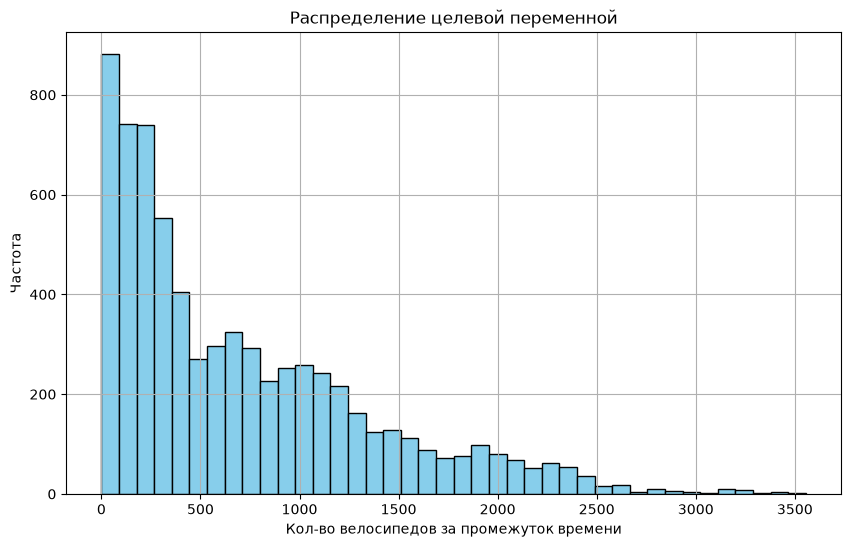

In [19]:
plt.figure(figsize=(10,6))
plt.hist(df_train['rented_bike_count'],
        bins=40,
        color='skyblue',
        edgecolor='black')
plt.grid()
plt.title('Распределение целевой переменной')
plt.xlabel('Кол-во велосипедов за промежуток времени')
plt.ylabel('Частота')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11032\3345266257.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_train['rented_bike_count'],


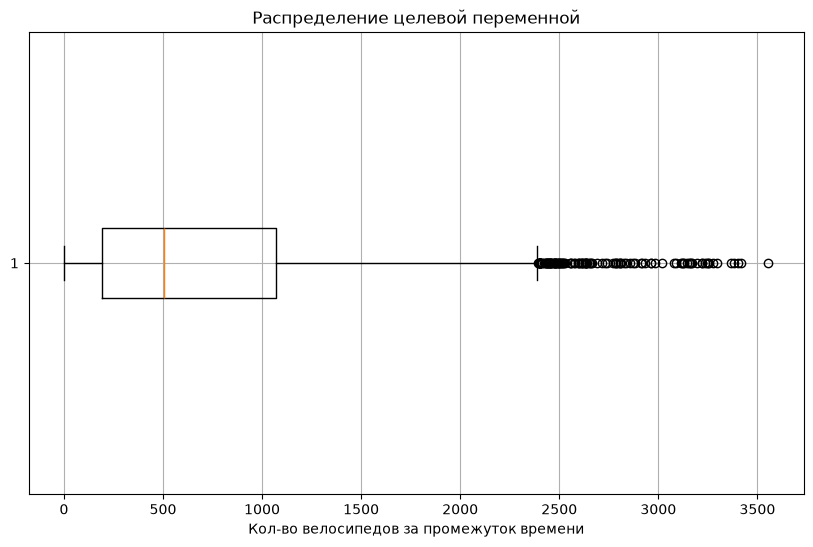

In [20]:
plt.figure(figsize=(10,6))
plt.boxplot(df_train['rented_bike_count'],
           vert=False)
plt.grid()
plt.title('Распределение целевой переменной')
plt.xlabel('Кол-во велосипедов за промежуток времени')
plt.show()

В целевой переменной наблюдается сильное смещение, что может говорить о наличии выбросов. На графиках видно что существуют значения более 2500. Изучим такие строчки:

In [21]:
print(f'Доля строк со значением выше 2500: {df_train[df_train["rented_bike_count"] > 2500].shape[0] / df_train.shape[0] * 100}')

Доля строк со значением выше 2500: 1.1130136986301369


In [22]:
df_train[df_train["rented_bike_count"] > 2500]

,temperature,humidity,wind_speed_ms,visibility_10m,dew_point_temperature,solar_radiation_mjm2,rainfallmm,snowfall_cm,seasons,holiday,functioning_day,time_period_evening,time_period_late_evening,time_period_morning,time_period_night,rented_bike_count
36,25.9,52.0,2.1,2000.0,15.2,0.57,0.0,0.0,Summer,No Holiday,Yes,True,False,False,False,3196
206,28.2,64.0,2.8,1978.0,20.7,0.50,0.0,0.0,Summer,No Holiday,Yes,True,False,False,False,2637
557,21.2,52.0,3.6,1856.0,10.9,0.55,0.0,0.0,Spring,No Holiday,Yes,True,False,False,False,2650
892,27.5,47.0,2.5,1113.0,15.1,0.43,0.0,0.0,Spring,No Holiday,Yes,True,False,False,False,2915
934,33.0,51.0,2.4,1566.0,21.5,1.23,0.0,0.0,Summer,No Holiday,Yes,True,False,False,False,2640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6558,28.1,60.0,1.9,959.0,19.5,1.05,0.0,0.0,Summer,No Holiday,Yes,True,False,False,False,3113
6602,23.3,68.0,3.6,895.0,17.0,0.11,0.0,0.0,Summer,No Holiday,Yes,False,True,False,False,2519
6729,28.4,75.0,NaN,1564.0,23.5,0.52,0.0,0.0,Summer,No Holiday,Yes,True,False,False,False,2931
6838,21.2,NaN,3.8,1927.0,3.8,0.94,0.0,0.0,Spring,No Holiday,Yes,True,False,False,False,2807


Всего существует 78 строк с выбросами. Считаю что данные выбросы могут нести в себе ценность т.к. они могут указывать на дни с аномально высоким спросом.

### Числовые признаки

Изучим следующие числовые признаки:
- `Temperature`
- `Humidity`
- `Windspeed`
- `Visibility`
- `Dew Point Temperature`
- `Solar Radiation`
- `Rainfall`
- `Snowfall`

In [31]:
num_cols = ['temperature', 'humidity', 'wind_speed_ms', 'visibility_10m', 'dew_point_temperature', 'solar_radiation_mjm2',
           'rainfallmm', 'snowfall_cm']

def num_col_describe(col, binsize):
    print(f'Сводка по столбцу {col}')
    print('')
    display(df_train[col].describe())
    print('')
    print(f'Кол-во пропусков в столбце {col}: {df_train[col].isna().sum()}')
    print(f'Доля пропусков в столбце {col}: {round(df_train[col].isna().sum() / df_train.shape[0], 2)}')
    plt.figure(figsize=(10,6))
    plt.hist(
        df_train[col],
        color='skyblue',
        edgecolor='black',
        alpha=0.7,
        bins=binsize
    )
    plt.grid()
    plt.xlabel(f'Значения {col}')
    plt.ylabel('Частота')
    plt.title(f'Распределение значений признака {col}')
    plt.show()
    print('=' * 50)

Пройдемся по каждому признаку по порядку:

#### Temperature

Признак означает температуру воздуха и имеет нормальное симметричное распределение. Пропуски отсутствуют. Никаких действий с данным признаком кроме масштабирования не требуется.

Сводка по столбцу temperature



count    7008.000000
mean       12.812914
std        11.924688
min       -17.500000
25%         3.300000
50%        13.500000
75%        22.400000
max        39.400000
Name: temperature, dtype: float64


Кол-во пропусков в столбце temperature: 0
Доля пропусков в столбце temperature: 0.0


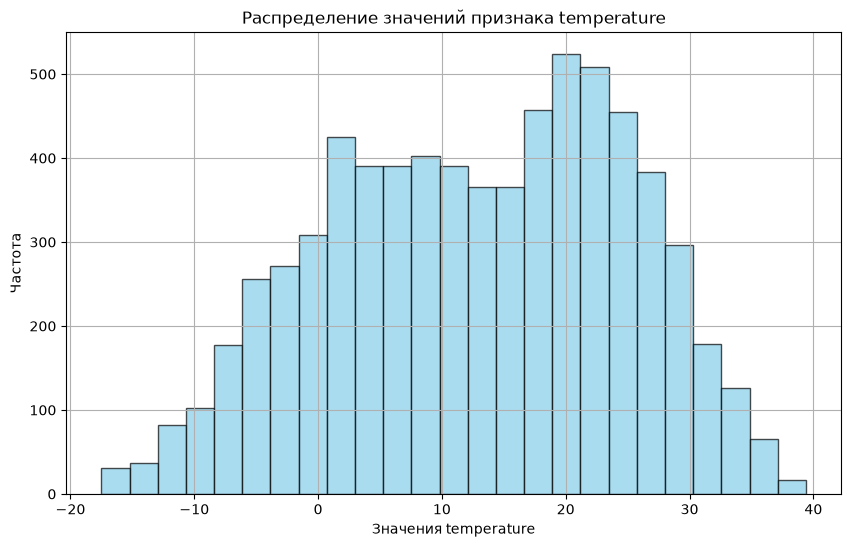

In [32]:
num_col_describe('temperature', 25)

#### Humidity

Сводка по столбцу humidity



count    6758.000000
mean       58.200503
std        20.340317
min         0.000000
25%        42.000000
50%        57.000000
75%        74.000000
max        98.000000
Name: humidity, dtype: float64


Кол-во пропусков в столбце humidity: 250
Доля пропусков в столбце humidity: 0.04


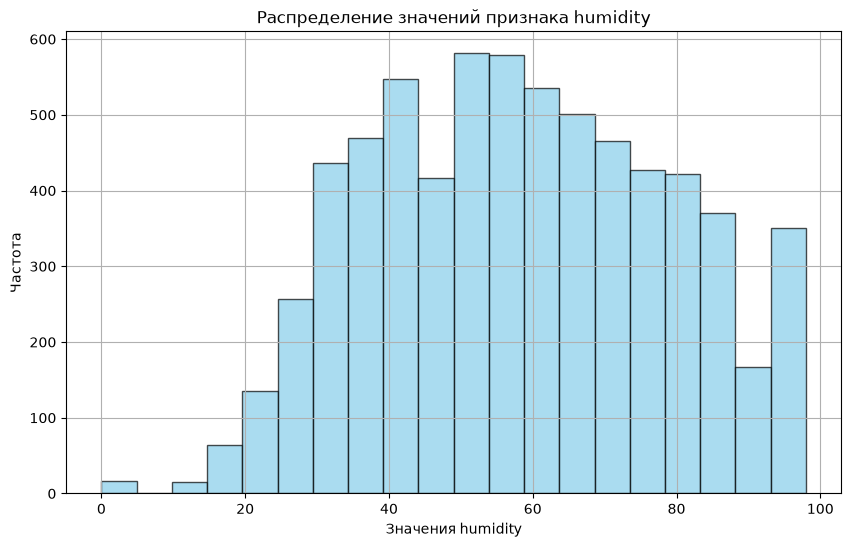

In [36]:
num_col_describe('humidity', 20)

Отражает относительную влажность воздуха. Распределение симметричное, выбросы отсутствуют. Присутствуют пропуски. Посмотрим на строки с пропусками:

In [25]:
df_train[df_train['humidity'].isna()]

,temperature,humidity,wind_speed_ms,visibility_10m,dew_point_temperature,solar_radiation_mjm2,rainfallmm,snowfall_cm,seasons,holiday,functioning_day,time_period_evening,time_period_late_evening,time_period_morning,time_period_night,rented_bike_count
23,23.8,NaN,0.6,2000.0,17.2,0.00,0.0,0.0,Autumn,No Holiday,Yes,False,True,False,False,2000
95,28.9,NaN,2.0,1975.0,14.6,2.50,0.0,0.0,Summer,No Holiday,Yes,False,False,False,False,1070
103,-10.3,NaN,2.0,2000.0,-19.2,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,77
115,15.5,NaN,1.7,2000.0,5.6,0.70,0.0,0.0,Spring,No Holiday,Yes,True,False,False,False,1118
131,6.2,NaN,0.6,1584.0,-1.2,0.00,0.0,NaN,Autumn,No Holiday,Yes,False,False,False,True,327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6891,24.3,NaN,1.8,1931.0,17.0,0.59,0.0,0.0,Summer,No Holiday,Yes,False,False,False,False,782
6921,-15.3,NaN,0.8,1963.0,-25.0,0.00,0.0,0.3,Winter,No Holiday,Yes,False,False,False,True,41
6923,33.2,NaN,2.6,1289.0,24.0,2.37,0.0,0.0,Summer,No Holiday,Yes,False,False,False,False,613
6936,11.4,NaN,1.0,885.0,8.0,0.02,0.0,0.0,Spring,No Holiday,No,False,False,True,False,0


Т.к. распределение симметричное, а кол-во пропусков небольшое - пропуски буду заполнять медианой. 

#### WindSpeed

Сводка по столбцу wind_speed_ms



count    6798.000000
mean        1.725228
std         1.042956
min         0.000000
25%         0.900000
50%         1.500000
75%         2.300000
max         7.400000
Name: wind_speed_ms, dtype: float64


Кол-во пропусков в столбце wind_speed_ms: 210
Доля пропусков в столбце wind_speed_ms: 0.03


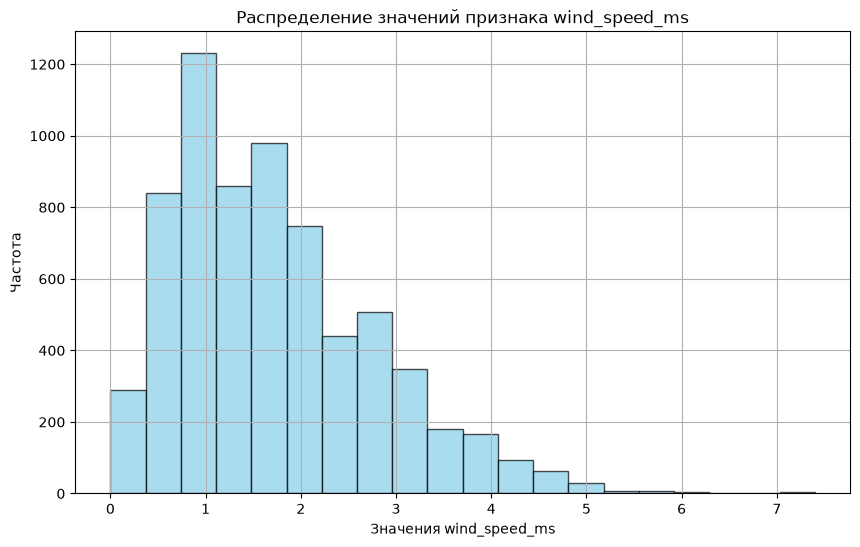

In [37]:
num_col_describe('wind_speed_ms', 20)

Распределение вытянуто вправо, но наличие выбросов характерно для скорости ветра. Редко, но бывают штормовые дни со скоростью ветра до 7 м/с. Такие выбросы в данных очень ценные, т.к. могут прогнозировать низкий спрос на велосипеды.

В признаке присутствуют 210 записей с пропусками. В препроцессоре заполним эти данные медианой.

#### Visibility

Сводка по столбцу visibility_10m



count    6749.000000
mean     1435.156764
std       607.291049
min        27.000000
25%       936.000000
50%      1691.000000
75%      2000.000000
max      2000.000000
Name: visibility_10m, dtype: float64


Кол-во пропусков в столбце visibility_10m: 259
Доля пропусков в столбце visibility_10m: 0.04


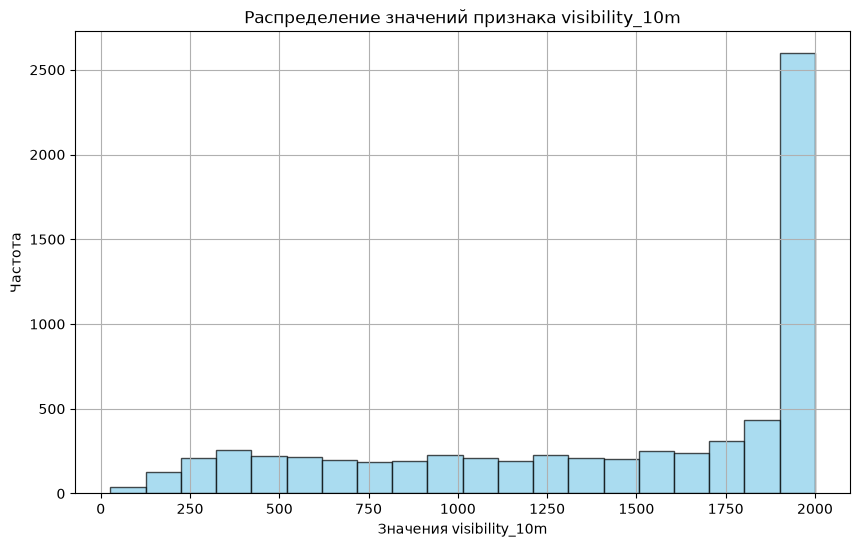

In [69]:
num_col_describe('visibility_10m', 20)

Признак отражает видимость в дестяках метрах. По гистограмме можно заметить что чаще всего видимость хорошая и составляет 20км. В данном признаке содержатся 259 строк с пропусками, которые можно будет заполнить медианой.

#### Dew Point Temperature

Сводка по столбцу dew_point_temperature



count    7008.000000
mean        4.021490
std        13.033377
min       -30.600000
25%        -4.700000
50%         5.000000
75%        14.800000
max        26.800000
Name: dew_point_temperature, dtype: float64


Кол-во пропусков в столбце dew_point_temperature: 0
Доля пропусков в столбце dew_point_temperature: 0.0


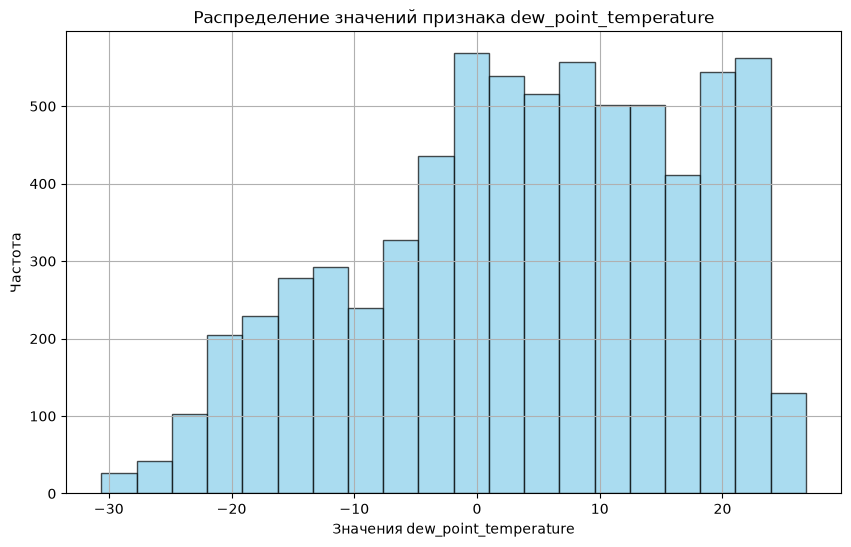

In [70]:
num_col_describe('dew_point_temperature', 20)

Признак отражает точку росы. Распределение - нормальное. Выбросы отсутствуют.

#### Solar Radiation

Сводка по столбцу solar_radiation_mjm2



count    6798.000000
mean        0.569885
std         0.866142
min         0.000000
25%         0.000000
50%         0.010000
75%         0.940000
max         3.520000
Name: solar_radiation_mjm2, dtype: float64


Кол-во пропусков в столбце solar_radiation_mjm2: 210
Доля пропусков в столбце solar_radiation_mjm2: 0.03


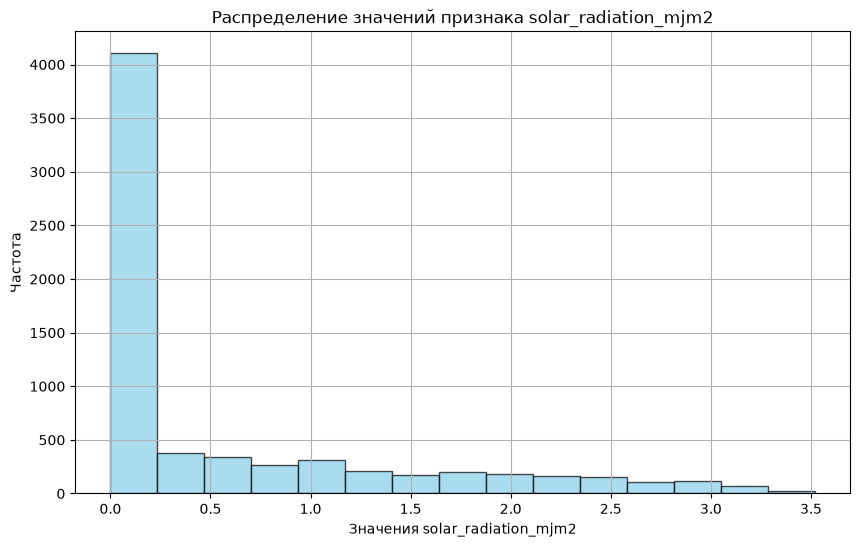

In [73]:
num_col_describe('solar_radiation_mjm2', 15)

Признак solar_radiation_mjm2 отражает значение солничной радиации. Расределение сильно смещенною Чаще всего значение данного признака находится около 0. Присутствуют 210 пропусков в данных. Заполним их медианой.

#### Rainfall

Сводка по столбцу rainfallmm



count    6746.000000
mean        0.146902
std         1.164118
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        35.000000
Name: rainfallmm, dtype: float64


Кол-во пропусков в столбце rainfallmm: 262
Доля пропусков в столбце rainfallmm: 0.04


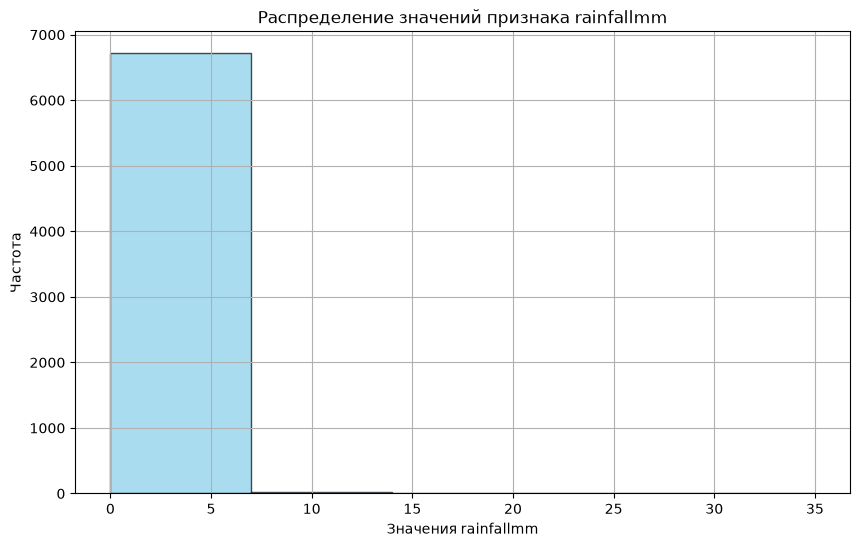

In [75]:
num_col_describe('rainfallmm', 5)

Признак rainfallmm показывает кол-во осадков в мм. Чаще всего осадки отсутствуют совсем. В признаке находится 262 признака. Т.к. осадки практически всегда отсутствуют - предлагаю запоолнить данные пропуски модой

#### Snowfall

Сводка по столбцу snowfall_cm



count    6745.000000
mean        0.074752
std         0.438189
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         8.800000
Name: snowfall_cm, dtype: float64


Кол-во пропусков в столбце snowfall_cm: 263
Доля пропусков в столбце snowfall_cm: 0.04


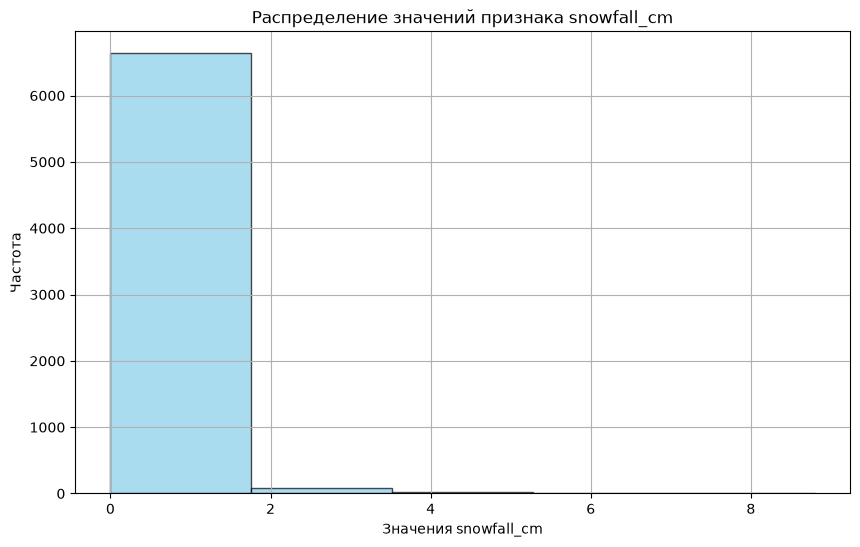

In [77]:
num_col_describe('snowfall_cm', 5)

Признак snowfall_cm показывает кол-во снега. Чаще всего снег отсутствует. По аналогии с rainfall предлагаю заполнить пропуски модой.

---

### Категориальные признаки

Рассмотрим категориальные признаки:
- `Seasons`
- `Holiday`
- `Functioning Day`
- `Time_Period`

In [84]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   temperature               7008 non-null   float64
 1   humidity                  6758 non-null   float64
 2   wind_speed_ms             6798 non-null   float64
 3   visibility_10m            6749 non-null   float64
 4   dew_point_temperature     7008 non-null   float64
 5   solar_radiation_mjm2      6798 non-null   float64
 6   rainfallmm                6746 non-null   float64
 7   snowfall_cm               6745 non-null   float64
 8   seasons                   7008 non-null   object 
 9   holiday                   7008 non-null   object 
 10  functioning_day           7008 non-null   object 
 11  time_period_evening       7008 non-null   bool   
 12  time_period_late_evening  7008 non-null   bool   
 13  time_period_morning       7008 non-null   bool   
 14  time_per

In [94]:
def cat_col_describe(col):
    print(f'Описание признака {col}')
    print('')
    print(f'Кол-во пропусков в столбце {col}: {df_train[col].isna().sum()}')
    print(f'Доля пропусков в столбце {col}: {round(df_train[col].isna().sum() / df_train.shape[0], 2)}')
    print('')
    plt.figure(figsize=(10,6))
    df_train[col].value_counts().plot(kind='bar',
                                      color='skyblue',
                                      edgecolor='black',
                                      alpha=0.7,
                                      rot=45,
                                      title=f'Распределение категорий {col}',
                                      xlabel='Название категории',
                                      ylabel='Частота')
    plt.grid()
    plt.show()

#### Seasons

Описание признака seasons

Кол-во пропусков в столбце seasons: 0
Доля пропусков в столбце seasons: 0.0



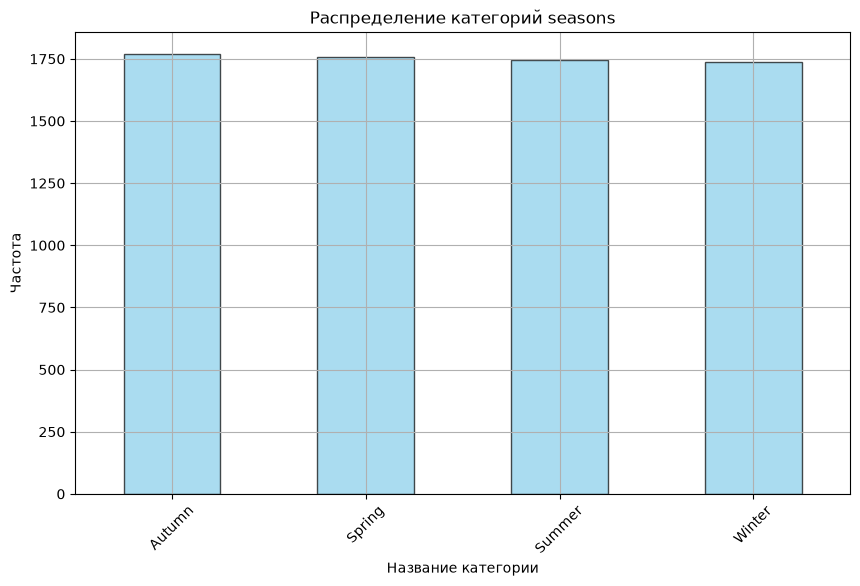

In [95]:
cat_col_describe('seasons')

Признак season содержит в себе информацию о времени года. Всего 4 категории, как и сезонов. Распределение о записях - нормальное. Пропуски отсутствуют.

#### Holiday

Описание признака holiday

Кол-во пропусков в столбце holiday: 0
Доля пропусков в столбце holiday: 0.0



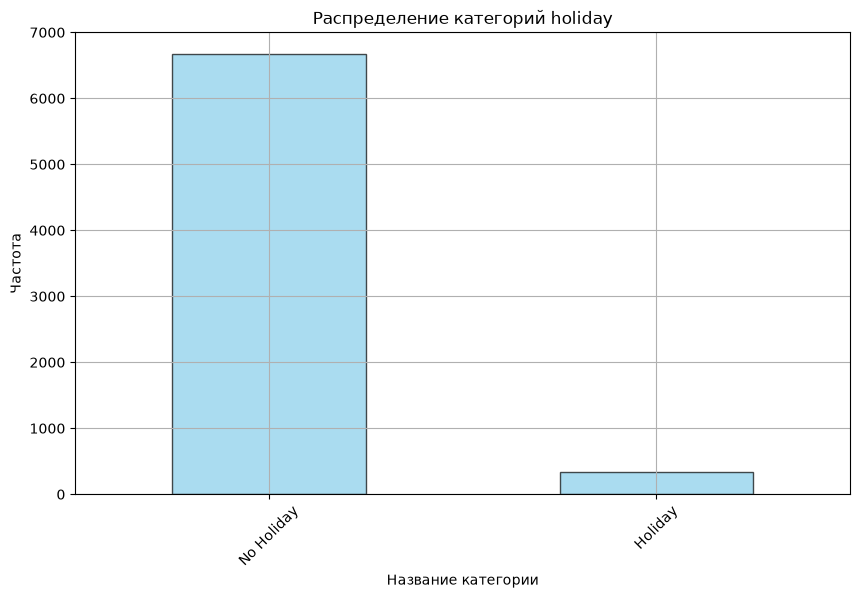

In [96]:
cat_col_describe('holiday')

Признак holiday отражает выходной/праздничный день записи. В контексте признака распределение нормальное. Обычные будние дни кратно превышают по количеству праздничные. Пропуски отсутствуют.

#### Functioning Day

Описание признака functioning_day

Кол-во пропусков в столбце functioning_day: 0
Доля пропусков в столбце functioning_day: 0.0



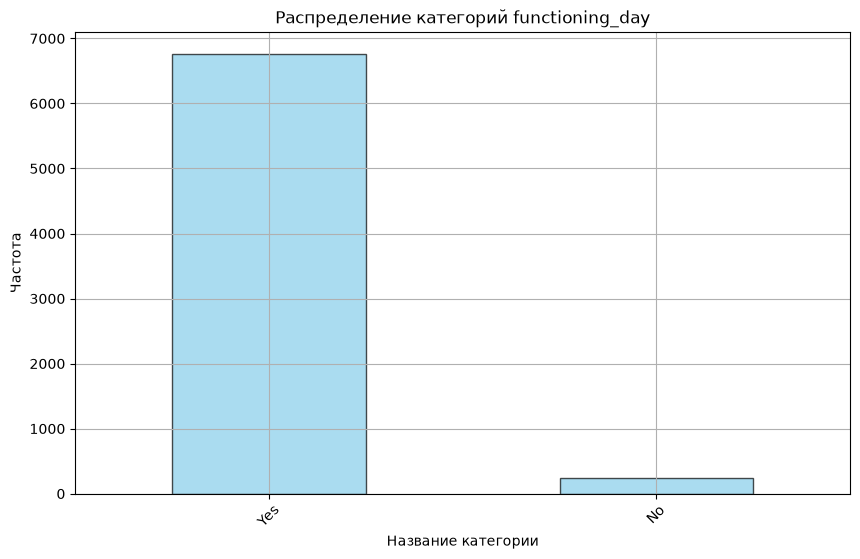

In [98]:
cat_col_describe('functioning_day')

Признак показывает работал ли прокат в момент записи, или был на тех обслуживании. Пропуски отсутсвуют.

#### Time_Period

Признак time_period закодирован с помощью OneHot. Такие признаки избавляют нас от необходимости кодирования в дальнейшем.

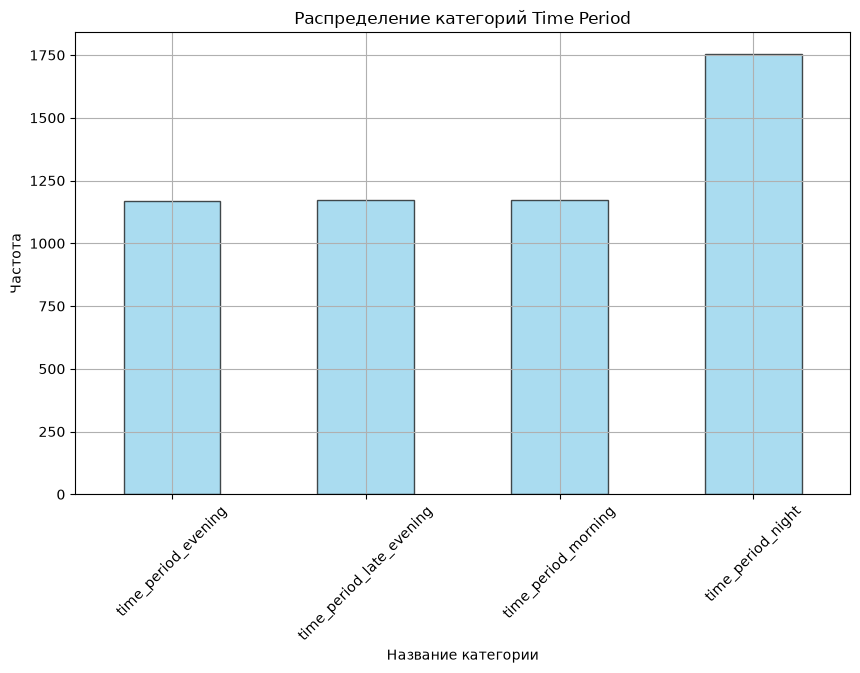

In [104]:
plt.figure(figsize=(10,6))
df_train[['time_period_evening', 'time_period_late_evening', 'time_period_morning', 'time_period_night']].sum().plot(kind='bar',
                                                                                                                     color='skyblue',
                                                                                                                     edgecolor='black',
                                                                                                                     alpha=0.7,
                                                                                                                     rot=45,
                                                                                                                     title=f'Распределение категорий Time Period',
                                                                                                                     xlabel='Название категории',
ylabel='Частота')
plt.grid()
plt.show()

После построения столбчатой диаграммы мы можем видеть, что самая поплуярное время - с 00:00 по 5:59. Однако, если во всех признаках стоит False - автоматически считается daytime. Посмотрим сколько раз была запись в дневное время:

In [110]:
print('Кол-во записей с 10:00 по 15:59:', df_train.shape[0] - df_train[['time_period_evening', 'time_period_late_evening', 'time_period_morning', 'time_period_night']].sum().sum())

Кол-во записей с 10:00 по 15:59: 1742


# **Авторское решение**